**PyML final project**

Made by: Liventseva Veronika, Kimsanbaev Shergazi, Zhukovskii Matvei

In [323]:
! pip install yfinance -q
import numpy as np
import pandas as pd
import yfinance as yf # API to finance data
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

This project is broken into 3 main parts - technical analysis, fundamental analysis and risk analysis.
Technical part is based on popular rules for technical analysis in trading - simple moving average, exponential moving average, RSI and Bollinger bands.
Fundamental part provides chosen company's most important financial indicators.
Risk part helps you to understand what losses you may face.

Overall, this project is designed to help you make an informed investment decision. All you need to do is enter the company's name you want to invest in and the amount of risk you are willing to take. We will take care of the rest and provide (almost) all information you need. Enjoy your investment!


First part - **Technical analysis**

In [344]:
class TechnicalRules:

    def __init__(self, ticker, start_date, end_date):
        """
        Input parameters are the following
        tickers - company's ticker 
        start_date - starting date for the data
        end_data - ending date for the data
        """
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.returns_data = {}
        self.prices_data = {}

    def data_download(self, basic_info=True):
        """
        Market data downloading using yahoo finance API
        """
        # Data downloading 
        self.data = yf.download(self.ticker, start=self.start_date, end=self.end_date, auto_adjust=False)
        price_close = self.data[('Adj Close', self.ticker)]
        self.prices_data[self.ticker] = price_close
        
        # Calculating log returns
        returns = np.log(price_close / price_close.shift(1)).dropna()
        self.returns_data[self.ticker] = returns

        if basic_info:
            print(f"{self.ticker}: Mean return = {returns.mean():.3f}, volatility of returns = {returns.std():.3f}")

    def __moving_average(self, window_short=50, window_long=100):
        """
        Moving average calculation (inner function)
        Parameters:
        window_short - window for short simple moving average (SMA) (50 days by default)
        window_long - window for long simple moving average (SMA) (100 days by default)
        """
        self.sma_window_short = window_short
        self.sma_window_long = window_long
        sma_short = self.data[('Adj Close', self.ticker)].rolling(window_short).mean()
        sma_long = self.data[('Adj Close', self.ticker)].rolling(window_long).mean()
        self.prices_data[self.ticker + f'_SMA_{window_short}'], self.prices_data[self.ticker + f'_SMA_{window_long}'] = sma_short, sma_long
        # return self.prices_data
    
    def __exponential_moving_average(self, window=50):
        """
        Exponential moving average calculation (inner function)
        Parameters:
        window_short - window for short exponential moving average (SMA) (50 days by default)
        window_long - window for long exponential moving average (SMA) (100 days by default)
        """
        self.ema_window = window
        alpha = 2 / (window + 1)
        ema = [self.prices_data[self.ticker].iloc[0]]
        for price in self.prices_data[self.ticker].iloc[1:]:
            ema.append(alpha * price + (1 - alpha) * ema[-1])
        self.prices_data[self.ticker + f'_EMA_{window}'] = ema
        # return self.prices_data
    
    def rsi_calculation(self, window=14):
        """
        Caluclation of Relative Strength Index (RSI)
        Parameters:
        window - window used for the calculations (14 days by default)
        """
        self.rsi_window = window
        U_list = []
        D_list = []
        close_prices = self.prices_data[self.ticker].iloc[-(window+1):]
        for i in range(len(close_prices) - 1):
            change = close_prices.iloc[i+1] - close_prices.iloc[i]
            if change > 0:
                U_list.append(change)
            else:
                D_list.append(change)
                
        RS = (sum(U_list) / window) / abs((sum(D_list) / window))
        self.RSI = 100 - (100 / (1 + RS))
        return self.RSI
    
    def __Bollinger_bands(self, window=20):
        """
        Bollinger bands calculation (inner function)
        Parameters:
        window - window parameter to use in SMA (20 by default)
        """
        self.bol_window = window
        sma_20 = self.data[('Adj Close', self.ticker)].rolling(window).mean()
        rolling_volatility = self.data[('Adj Close', self.ticker)].rolling(window).std()
        self.prices_data[self.ticker + f'_bol_SMA_{window}'] = sma_20
        self.prices_data[self.ticker + f'_bol_volatility_{window}'] = rolling_volatility
        self.prices_data[self.ticker + f'_bol_band_upper_{window}'] = sma_20 + 2 * rolling_volatility
        self.prices_data[self.ticker + f'_bol_band_lower_{window}'] = sma_20 - 2 * rolling_volatility
        # return self.prices_data
    
    def moving_average_analysis(self, window_sma_short=None, window_sma_long=None, window_ema=None, window_bollinger=None):
        """ 
        This function aims to initialize the inner functions for moving average analysis
        Windows are the parameters
        """
        if window_sma_short:
            self.__moving_average(window_short=window_sma_short)
        elif window_sma_short and window_sma_long:
            self.__moving_average(window_short=window_sma_short, window_long=window_sma_long)
        else:
            self.__moving_average()
        
        if window_ema:
            self.__exponential_moving_average(window=window_ema)
        else:
            self.__exponential_moving_average()
        
        if window_bollinger:
            self.__Bollinger_bands(window=window_bollinger)
        else:
            self.__Bollinger_bands()
            
        return self.prices_data
    
    def technical_results(self):
        """Getting technical summary"""
        data = self.moving_average_analysis()
        rsi = round(self.rsi_calculation(), 2)
        last_price = round(data[self.ticker].iloc[-1], 3)
        last_sma_short = round(data[self.ticker + f'_SMA_{self.sma_window_short}'].iloc[-1], 3)
        last_sma_long = round(data[self.ticker + f'_SMA_{self.sma_window_long}'].iloc[-1], 3)
        last_ema = round(data[self.ticker + f'_EMA_{self.ema_window}'][-1], 3)
        last_upper_bol_band = round(data[self.ticker + f'_bol_band_upper_{self.bol_window}'].iloc[-1], 3)
        last_lower_bol_band = round(data[self.ticker + f'_bol_band_lower_{self.bol_window}'].iloc[-1], 3)

        tech_result = {
            'Last price' : last_price,
            f'SMA short ({self.sma_window_short})' : last_sma_short,
            f'SMA long ({self.sma_window_long})' : last_sma_long,
            f'EMA ({self.ema_window})' : last_ema,
            f'Upper Bollinger band ({self.bol_window})' : last_upper_bol_band,
            f'Lower Bollinger band ({self.bol_window})' : last_lower_bol_band,
            f'RSI {self.rsi_window}' : rsi
        }

        # Printing technical rules
        # 1) Based on SMA
        if last_sma_short > last_sma_long:
            print("Golden cross - signal to BUY")
        elif last_sma_short < last_sma_long:
            print("Death cross - signal to SELL")
        
        # 2) Based on EMA
        if last_price > last_ema:
            print("Upward trend")
        else:
            print("Downward trend")
        
        # 3) Based on Bollinger bands
        if last_price < last_lower_bol_band:
            print("Oversold - signal to BUY")
        elif last_price > last_upper_bol_band:
            print("Overbought - signal to SELL")
        else:
            print("Boolinger-based analysis is neutral")

        # 4) Based on RSI
        if rsi < 30:
            print(f"RSI = {rsi}, oversold - signal to BUY")
        elif rsi > 70:
            print(f"RSI = {rsi}, overbought - signal to SELL")
        elif 40 < rsi < 60:
            print(f"RSI = {rsi} - neutral signal")

        # 5) Final recomendation (Strong buy or strong sell)
        if last_sma_short > last_sma_long and last_price > last_ema and last_price < last_lower_bol_band and rsi < 30:
            print("STRONG BUY")
        elif last_sma_short < last_sma_long and last_price < last_ema and last_price > last_upper_bol_band and rsi > 70:
            print("STRONG SELL")
        else:
            print("No definite signal, you should look yourself")


        return tech_result


In [345]:
# Importing data and getting the results of technical analysis
ticker = input("Enter chose company's ticker (like AAPL for Apple)")
years_of_analysis = 5
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=365*years_of_analysis)
aapl = TechnicalRules(ticker, start_date=start_date, end_date=end_date)
aapl.data_download()
print(aapl.technical_results())

[*********************100%***********************]  1 of 1 completed

AAPL: Mean return = 0.001, volatility of returns = 0.017
Death cross - signal to SELL
Downward trend
Boolinger-based analysis is neutral
RSI = 25.66, oversold - signal to BUY
No definite signal, you should look yourself
{'Last price': 248.96, 'SMA short (50)': 261.27, 'SMA long (100)': 267.008, 'EMA (50)': 261.786, 'Upper Bollinger band (20)': 275.72, 'Lower Bollinger band (20)': 245.915, 'RSI 14': 25.66}


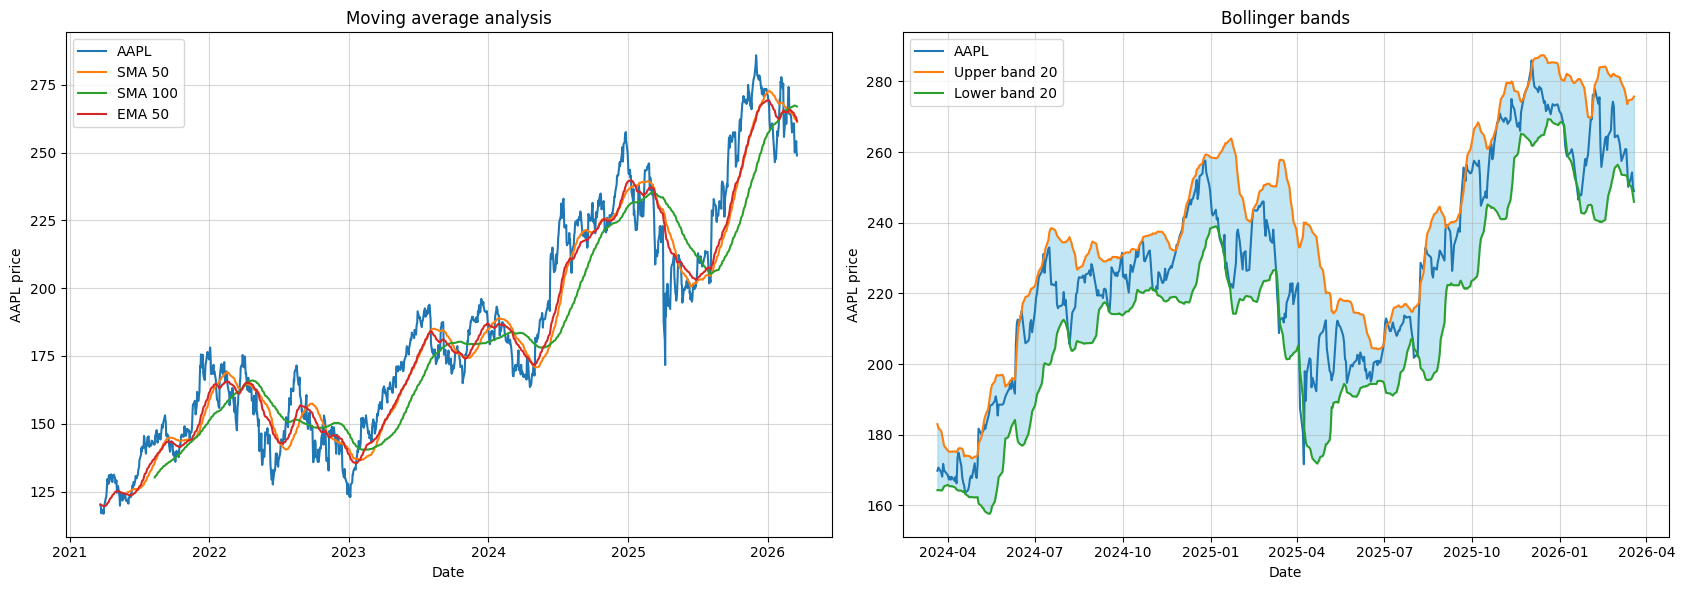

In [361]:
# Visualizing
window_sma_short, window_sma_long, window_ema, window_bollinger = 50, 100, 50, 20
price_data = aapl.moving_average_analysis(window_sma_short, window_sma_long, window_ema, window_bollinger)
n = len(price_data[ticker])

x_0 = price_data[ticker].index
fig, axes = plt.subplots(1, 2, figsize=(17,6))
sns.lineplot(x=x_0, y=price_data[ticker], ax=axes[0], label=f'{ticker}')
sns.lineplot(x=x_0, y=price_data[ticker + f'_SMA_{window_sma_short}'], ax=axes[0], label=f'SMA {window_sma_short}')
sns.lineplot(x=x_0, y=price_data[ticker + f'_SMA_{window_sma_long}'], ax=axes[0], label=f'SMA {window_sma_long}')
sns.lineplot(x=x_0, y=price_data[ticker + f'_EMA_{window_ema}'], ax=axes[0], label=f'EMA {window_ema}')
axes[0].grid(alpha=0.5)
axes[0].set_ylabel(f'{ticker} price')
axes[0].set_title('Moving average analysis')

period_bol = int(input(f'Enter any number of days for Bollinger analysis, but no more than {n}'))
x_1 = price_data[ticker].index[-period_bol:]
sns.lineplot(x=x_1, y=price_data[ticker].iloc[-period_bol:], ax=axes[1], label=f'{ticker}')
sns.lineplot(x=x_1, y=price_data[ticker + f'_bol_band_upper_{window_bollinger}'].iloc[-period_bol:], ax=axes[1], label=f'Upper band {window_bollinger}')
sns.lineplot(x=x_1, y=price_data[ticker + f'_bol_band_lower_{window_bollinger}'].iloc[-period_bol:], ax=axes[1], label=f'Lower band {window_bollinger}')
axes[1].fill_between(x_1, price_data[ticker + f'_bol_band_upper_{window_bollinger}'].iloc[-period_bol:], price_data[ticker + f'_bol_band_lower_{window_bollinger}'].iloc[-period_bol:], color='skyblue', alpha=0.5, label='Fill Area')
axes[1].grid(alpha=0.5)
axes[1].set_ylabel(f'{ticker} price')
axes[1].set_title('Bollinger bands')

plt.tight_layout()
plt.savefig("C:/Users/matve/OneDrive/Рабочий стол/ICEF/Studyings/Courses/Python for ML/technical analysis.png", dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

Second part - **Fundamental analysis**

In [352]:
class FundamentalAnalysis():

    def __init__(self, ticker):
        self.ticker = ticker

    def get_fundamentals(self):
        """Getting company's fundamentals"""
        ticker_obj = yf.Ticker(self.ticker)
        
        # Company's info
        info = ticker_obj.info
        
        fundamentals = {
            # Multiples
            'P/E': info.get('trailingPE', None), 
            'P/B': info.get('priceToBook', None), 
            'P/S': info.get('priceToSalesTrailing12Months', None),
            'EV/EBITDA': info.get('enterpriseToEbitda', None),
            
            # Profitability
            'ROE': info.get('returnOnEquity', None), 
            'ROA': info.get('returnOnAssets', None),  
            'Gross Margin': info.get('grossMargins', None),
            'Profit Margin': info.get('profitMargins', None),
            
            # Debt and liquidity
            'Debt/Equity': info.get('debtToEquity', None),
            'Current Ratio': info.get('currentRatio', None),
            'Quick Ratio': info.get('quickRatio', None),
            
            # Growth
            'Revenue Growth': info.get('revenueGrowth', None),
            'Earnings Growth': info.get('earningsGrowth', None),
            
            # Dividends
            'Dividend Yield': info.get('dividendYield', None),
            'Payout Ratio': info.get('payoutRatio', None),
            
            # Market capitalization
            'Market Cap': info.get('marketCap', None),
        }
        
        return fundamentals

    def fundamental_score(self):
        """Fundamental scores (only some basic rules)"""
        fundamentals = self.get_fundamentals()
        score = 0
        reasons = []
        
        # Rules for scoring
        if fundamentals['P/E'] and fundamentals['P/E'] < 15:
            score += 1
            reasons.append("P/E < 15 (undervalued)")
        elif fundamentals['P/E'] and fundamentals['P/E'] > 25:
            score -= 1
            reasons.append("P/E > 25 (overvalued)")
        
        if fundamentals['ROE'] and fundamentals['ROE'] > 0.15:
            score += 1
            reasons.append(f"ROE > 15% (good one) ({fundamentals['ROE']:.1%})")
        
        if fundamentals['Debt/Equity'] and fundamentals['Debt/Equity'] < 0.5:
            score += 1
            reasons.append("Debt level is low")
        
        if fundamentals['Revenue Growth'] and fundamentals['Revenue Growth'] > 0.1:
            score += 1
            reasons.append(f"High revenue growth ({fundamentals['Revenue Growth']:.1%})")
        
        return score, reasons

In [353]:
fundamental = FundamentalAnalysis(ticker)
print(fundamental.get_fundamentals())
print(f"Score = {fundamental.fundamental_score()[0]}, reasons for that - {fundamental.fundamental_score()[1]}")

{'P/E': 31.577314, 'P/B': 41.538013, 'P/S': 8.406271, 'EV/EBITDA': 24.059, 'ROE': 1.5202099, 'ROA': 0.24377, 'Gross Margin': 0.47325, 'Profit Margin': 0.27037, 'Debt/Equity': 102.63, 'Current Ratio': 0.974, 'Quick Ratio': 0.845, 'Revenue Growth': 0.157, 'Earnings Growth': 0.183, 'Dividend Yield': 0.42, 'Payout Ratio': 0.1304, 'Market Cap': 3661914701824}
Score = 1, reasons for that - ['P/E > 25 (overvalued)', 'ROE > 15% (good one) (152.0%)', 'High revenue growth (15.7%)']


Last part - **Risks analysis**

In [354]:
# This class will inherit some methods from 'TechnicalRules'
class VaRCalculator(TechnicalRules):
    
    def __init__(self, ticker, start_date, end_date, confidence_level=0.95, portfolio_value = 1000000):
        """
        Parameters are the following:
        ticker - inhereted from TechnicalRules
        start_date - inhereted from TechnicalRules
        end_date - inhereted from TechnicalRules
        confidence_level - confidence level => alpha = 0.05
        """
        super().__init__(ticker, start_date, end_date)
        
        # New attributes
        self.confidence_level = confidence_level
        self.portfolio_value = portfolio_value
        self.alpha = 1 - confidence_level 

        # We also download the data we need
        self.data_download(False)

    def __historical_var(self, window=252):
        """
        Historical VaR calculation 
        window - window for the data (252 by default - number of trading days in a year)
        """
        portfolio_value = self.portfolio_value
        portfolio_returns = self.returns_data[self.ticker]
        recent_returns = portfolio_returns.iloc[-window:]
        sorted_returns = np.sort(recent_returns)
        
        # Getting percentile we need
        var_percentile = 1 - self.confidence_level
        var_index = int(var_percentile * len(sorted_returns))

        # Now we can calculate VaR (and CVaR)
        var_percentage = sorted_returns[var_index]
        cvar_percentage = np.mean(sorted_returns[:var_index])
        var_monetary = portfolio_value * abs(var_percentage)
        cvar_monetary = portfolio_value * abs(cvar_percentage)
        
        # Additional statistics
        worst_return = sorted_returns[0]
        best_return = sorted_returns[-1]
        mean_return = recent_returns.mean()
        std_return = recent_returns.std()
        
        results = {
            'method': 'Historical VaR',
            'confidence_level': self.confidence_level,
            'window_days': window,
            'var_percentage': var_percentage,
            'var_monetary': var_monetary,
            'cvar_percentage' : cvar_percentage,
            'cvar_monetary' : cvar_monetary,
            'portfolio_value': portfolio_value,
            'worst_return': worst_return,
            'best_return': best_return,
            'mean_return': mean_return,
            'std_return': std_return,
            'returns_data': recent_returns
        }
        
        self.__print_var_results(results)
        return results
    
    def __monte_carlo_var(self, simulations=10000, days=1):
        """
        Monte Carlo VaR calculation
        We will simulate 'simulations' number of paths    
        """
        portfolio_value = self.portfolio_value
        portfolio_returns = self.returns_data[self.ticker]
        mean_return = portfolio_returns.mean()
        std_return = portfolio_returns.std()
        
        # Generating random returns for 'days' periods ahead
        np.random.seed(42) 
        random_returns = np.random.normal(mean_return, std_return, (simulations, days))
        
        # Total return for the period
        if days > 1:
            total_returns = np.sum(random_returns, axis=1)
        else:
            total_returns = random_returns.flatten()
        
        # Percentile calculations
        sorted_returns = np.sort(total_returns)
        var_percentile = 1 - self.confidence_level
        var_index = int(var_percentile * len(sorted_returns))

        # Getting the Monte Carlo VaR
        var_percentage = sorted_returns[var_index]
        cvar_percentage = np.mean(sorted_returns[:var_index])
        var_monetary = portfolio_value * abs(var_percentage)
        cvar_monetary = portfolio_value * abs(cvar_percentage)
        
        # Simulation statistics
        mean_simulated = total_returns.mean()
        std_simulated = total_returns.std()
        worst_simulated = sorted_returns[0]
        
        results = {
            'method': 'Monte Carlo VaR',
            'confidence_level': self.confidence_level,
            'simulations': simulations,
            'days': days,
            'var_percentage': var_percentage,
            'var_monetary': var_monetary,
            'cvar_percentage' : cvar_percentage,
            'cvar_monetary' : cvar_monetary,
            'portfolio_value': portfolio_value,
            'mean_simulated': mean_simulated,
            'std_simulated': std_simulated,
            'worst_simulated': worst_simulated,
            'simulated_returns': total_returns
        }
        
        self.__print_var_results(results)
        return results       

    def calculate_all_var(self):
        """
        Combining both methods
        """

        portfolio_value = self.portfolio_value
        print(f"Confidence level: {self.confidence_level*100}%")
        print(f"Portfolio value: {portfolio_value:,.2f}")
        
        results = {}
        
        # Using both methods to calculate VaR
        results['historical'] = self.__historical_var(portfolio_value)
        results['monte_carlo'] = self.__monte_carlo_var(portfolio_value)
        results['Log returns'] = self.returns_data[self.ticker]
        
        return results
    
    def __print_var_results(self, results):
        """VaR results"""

        print()
        print(f"Method: {results['method']}")
        print(f"Confidence level: {results['confidence_level']*100:.1f}%")
        print(f"VaR (%): {results['var_percentage']*100:.4f}%")
        print(f"VaR (monetary loss): {results['var_monetary']:,.2f}")
        print(f"CVaR (%): {results['cvar_percentage']*100:.4f}%")
        print(f"CVaR (monetary loss): {results['cvar_monetary']:,.2f}")
        print(f"Portfolio value: {results['portfolio_value']:,.2f}")
        
        if 'mean_return' in results:
            print(f"Mean return: {results['mean_return']*100:.4f}%")
            print(f"Standard deviation: {results['std_return']*100:.4f}%")

In [355]:
portfolio_value = int(input("Enter your portfolio value"))
calculator = VaRCalculator(
    ticker=ticker,
    start_date=start_date,
    end_date=end_date,
    portfolio_value=portfolio_value
)
results = calculator.calculate_all_var()

[*********************100%***********************]  1 of 1 completed

Confidence level: 95.0%
Portfolio value: 5,000.00

Method: Historical VaR
Confidence level: 95.0%
VaR (%): -2.7562%
VaR (monetary loss): 137.81
CVaR (%): -3.9622%
CVaR (monetary loss): 198.11
Portfolio value: 5,000.00
Mean return: 0.0581%
Standard deviation: 1.7238%

Method: Monte Carlo VaR
Confidence level: 95.0%
VaR (%): -2.7234%
VaR (monetary loss): 136.17
CVaR (%): -3.5102%
CVaR (monetary loss): 175.51
Portfolio value: 5,000.00


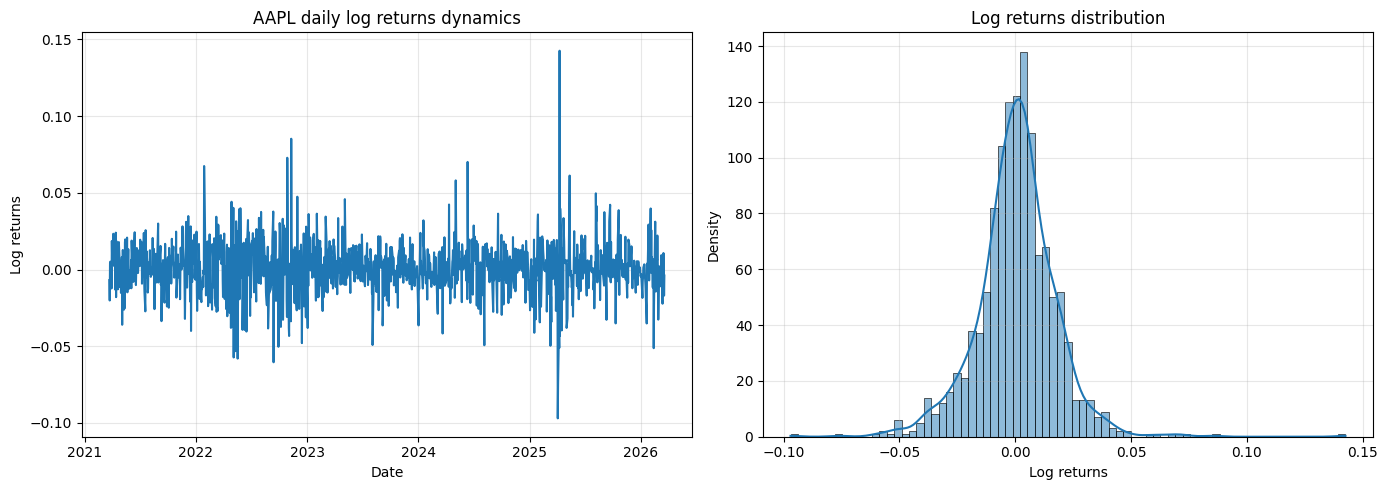

In [356]:
# Visualizing log returns
log_returns = pd.DataFrame(results['Log returns'])
log_returns.columns = ['log_returns']

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.lineplot(x=log_returns.index, y=log_returns.log_returns, ax=axes[0])
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log returns')
axes[0].set_title(f'{ticker} daily log returns dynamics')
axes[0].grid(alpha=0.3) 

sns.histplot(log_returns.log_returns, kde=True, ax=axes[1])
axes[1].set_xlabel('Log returns')
axes[1].set_ylabel('Density')
axes[1].set_title('Log returns distribution')
axes[1].grid(alpha=0.3) 

plt.tight_layout()
# plt.savefig("C:\\Users\\matve\\OneDrive\\Рабочий стол\\Программирование\\Прочие проекты\\Log-returns.png", dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

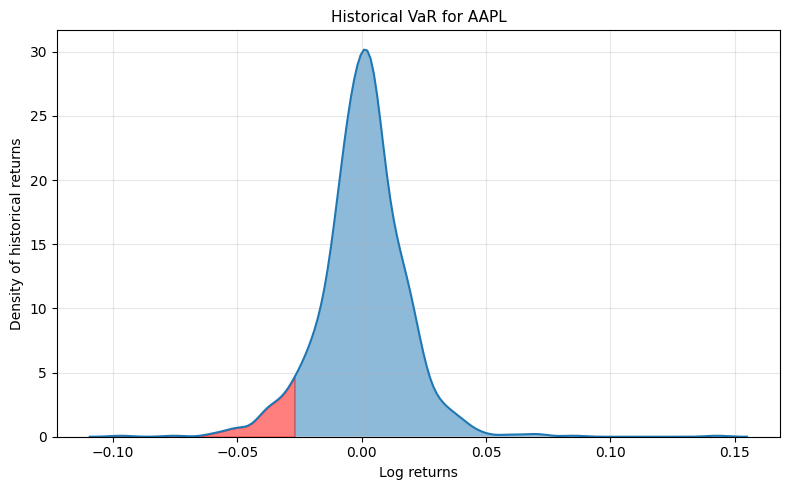

In [360]:
# Historical VaR visualization
log_returns_historic = pd.DataFrame(results['historical']['returns_data'])
log_returns_historic.columns = ['recent_log_returns']

plt.figure(figsize=(8,5))

ax = sns.kdeplot(log_returns_historic.recent_log_returns)
kde_line = ax.lines[0]
x_data, y_data = kde_line.get_xdata(), kde_line.get_ydata()
index_x = (list(x_data) < results['historical']['var_percentage']).sum()
index_y = y_data[index_x]

v_line_x = results['historical']['var_percentage'] 
plt.fill_between(x_data, y_data, color='r', alpha=0.5, where=(x_data <= v_line_x + 1e-3)) 
plt.fill_between(x_data, y_data, alpha=0.5, where=(x_data > v_line_x))
plt.title(f'Historical VaR for {ticker}', fontsize=11)
plt.xlabel('Log returns')
plt.ylabel('Density of historical returns')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("C:/Users/matve/OneDrive/Рабочий стол/ICEF/Studyings/Courses/Python for ML/historical.png", dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

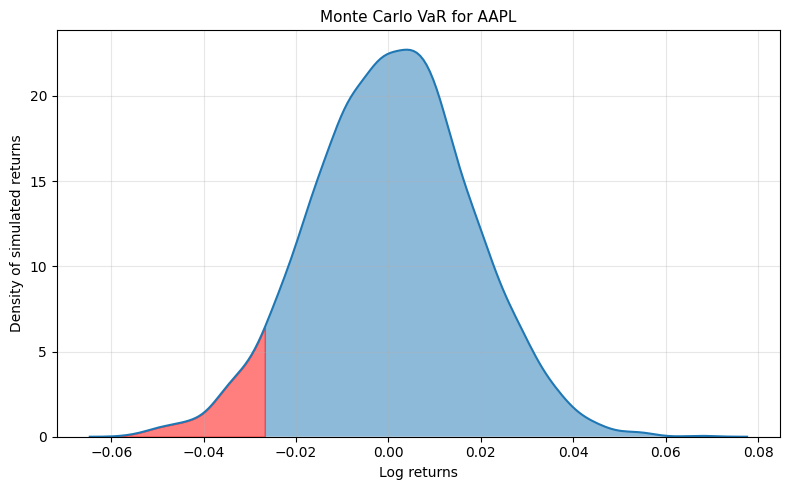

In [359]:
# Monte Carlo VaR visualization
log_returns_MC = pd.DataFrame(results['monte_carlo']['simulated_returns'])
log_returns_MC.columns = ['simulated_log_returns']

plt.figure(figsize=(8,5))

ax = sns.kdeplot(log_returns_MC.simulated_log_returns)
kde_line = ax.lines[0]
x_data, y_data = kde_line.get_xdata(), kde_line.get_ydata()
index_x = (list(x_data) < results['monte_carlo']['var_percentage']).sum()

v_line_x = results['monte_carlo']['var_percentage'] 
plt.fill_between(x_data, y_data, color='r', alpha=0.5, where=(x_data <= v_line_x + 1e-3)) 
plt.fill_between(x_data, y_data, alpha=0.5, where=(x_data >= v_line_x))
plt.title(f'Monte Carlo VaR for {ticker}', fontsize=11)
plt.xlabel('Log returns')
plt.ylabel('Density of simulated returns')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("C:/Users/matve/OneDrive/Рабочий стол/ICEF/Studyings/Courses/Python for ML/monte-carlo.png", dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()